# Strategy Performance Analysis Report

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from backtesting import *

""" 
from google.colab import drive
drive.mount('/content/drive') 
"""

" \nfrom google.colab import drive\ndrive.mount('/content/drive') \n"

In [2]:
PATH = "./backtest_outputs.csv"

In [3]:
df = pd.read_csv(PATH)
df.head()

,date,benchmark,signals_lstm,cum_return_ideal_lstm,cum_return_real_lstm,signals_xgb,cum_return_ideal_xgb,cum_return_real_xgb,signals_arima,cum_return_ideal_arima,cum_return_real_arima,signals_ridge,cum_return_ideal_ridge,cum_return_real_ridge
0,2025-08-31 20:58:00-04:00,1.000213,-0.572398,0.999878,1.000000,0.986283,1.000210,1.000112,-0.713082,0.999848,0.999777,0.581061,0.998327,0.99901
1,2025-08-31 20:59:00-04:00,1.000427,-0.047217,0.999868,1.000000,0.924786,1.000408,1.000303,-0.674389,0.999704,0.999629,0.462317,0.998426,0.99901
2,2025-08-31 21:00:00-04:00,0.999527,-0.568267,1.000379,1.000000,0.601836,0.999866,0.999729,-0.403796,1.000067,0.999562,0.405460,0.998512,0.99901
3,2025-08-31 21:01:00-04:00,1.000352,0.602734,1.000877,1.000437,0.519658,1.000295,0.999669,0.289057,1.000306,0.999562,0.367838,0.998182,0.99901
4,2025-08-31 21:02:00-04:00,1.000111,0.945629,1.000649,1.000175,0.866351,1.000086,0.999374,-0.338505,1.000388,0.999562,0.519742,0.998610,0.99901


**Reasoning**:
Convert the 'date' column to datetime objects and verify the data types as requested.



In [4]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
print(df.dtypes)
# df

benchmark                 float64
signals_lstm              float64
cum_return_ideal_lstm     float64
cum_return_real_lstm      float64
signals_xgb               float64
cum_return_ideal_xgb      float64
cum_return_real_xgb       float64
signals_arima             float64
cum_return_ideal_arima    float64
cum_return_real_arima     float64
signals_ridge             float64
cum_return_ideal_ridge    float64
cum_return_real_ridge     float64
dtype: object


## Trading Signals

/Users/yishanranxin./Desktop/codebase/backtesting/backtesting.py:536: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


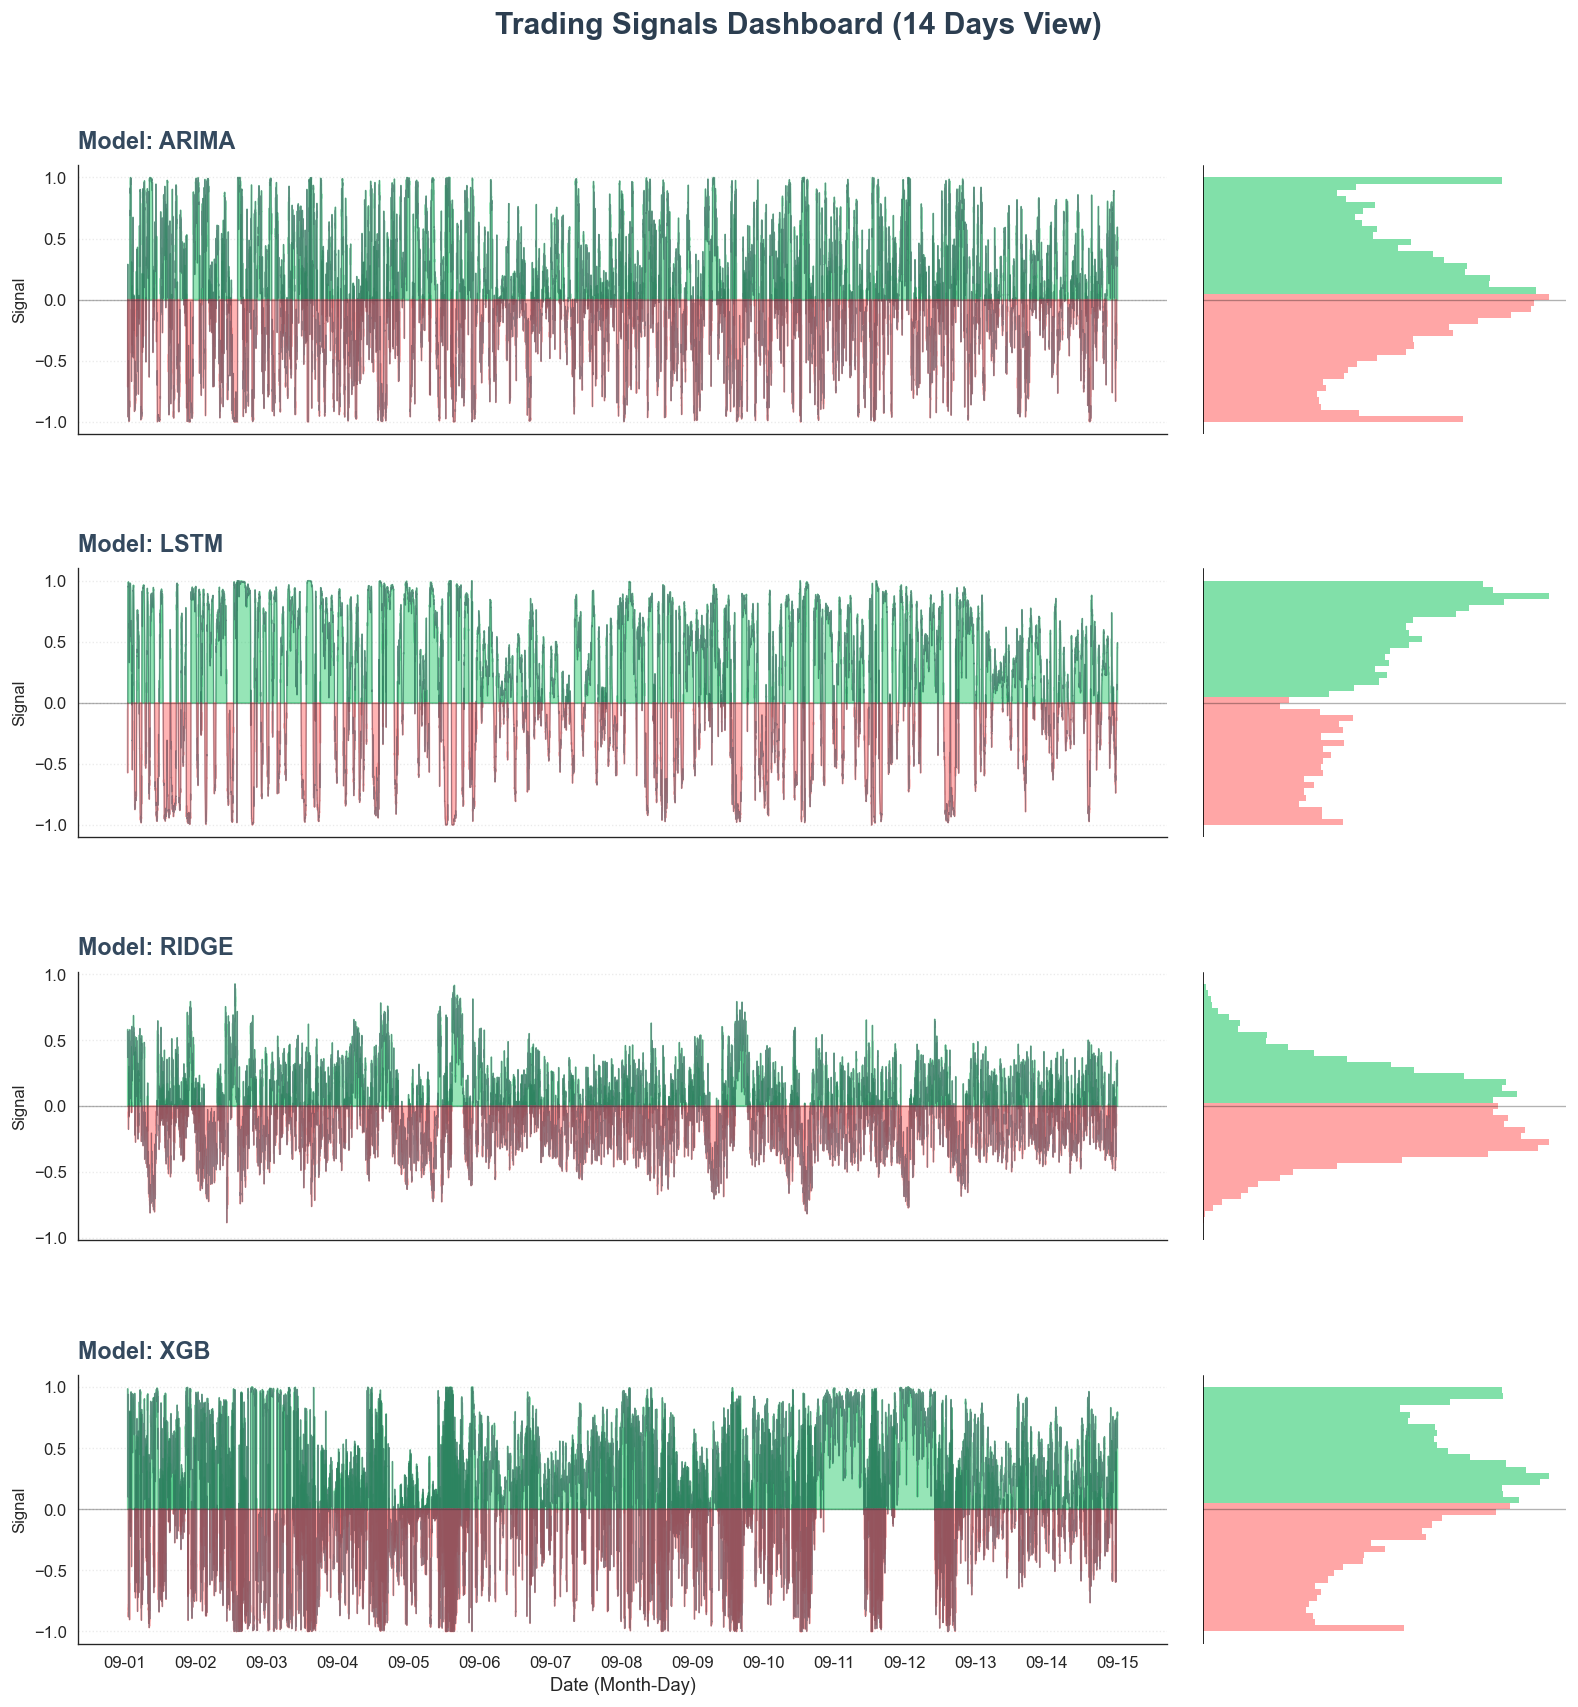

In [5]:
plot_red_green_dashboard(df)

## Backtesting Results

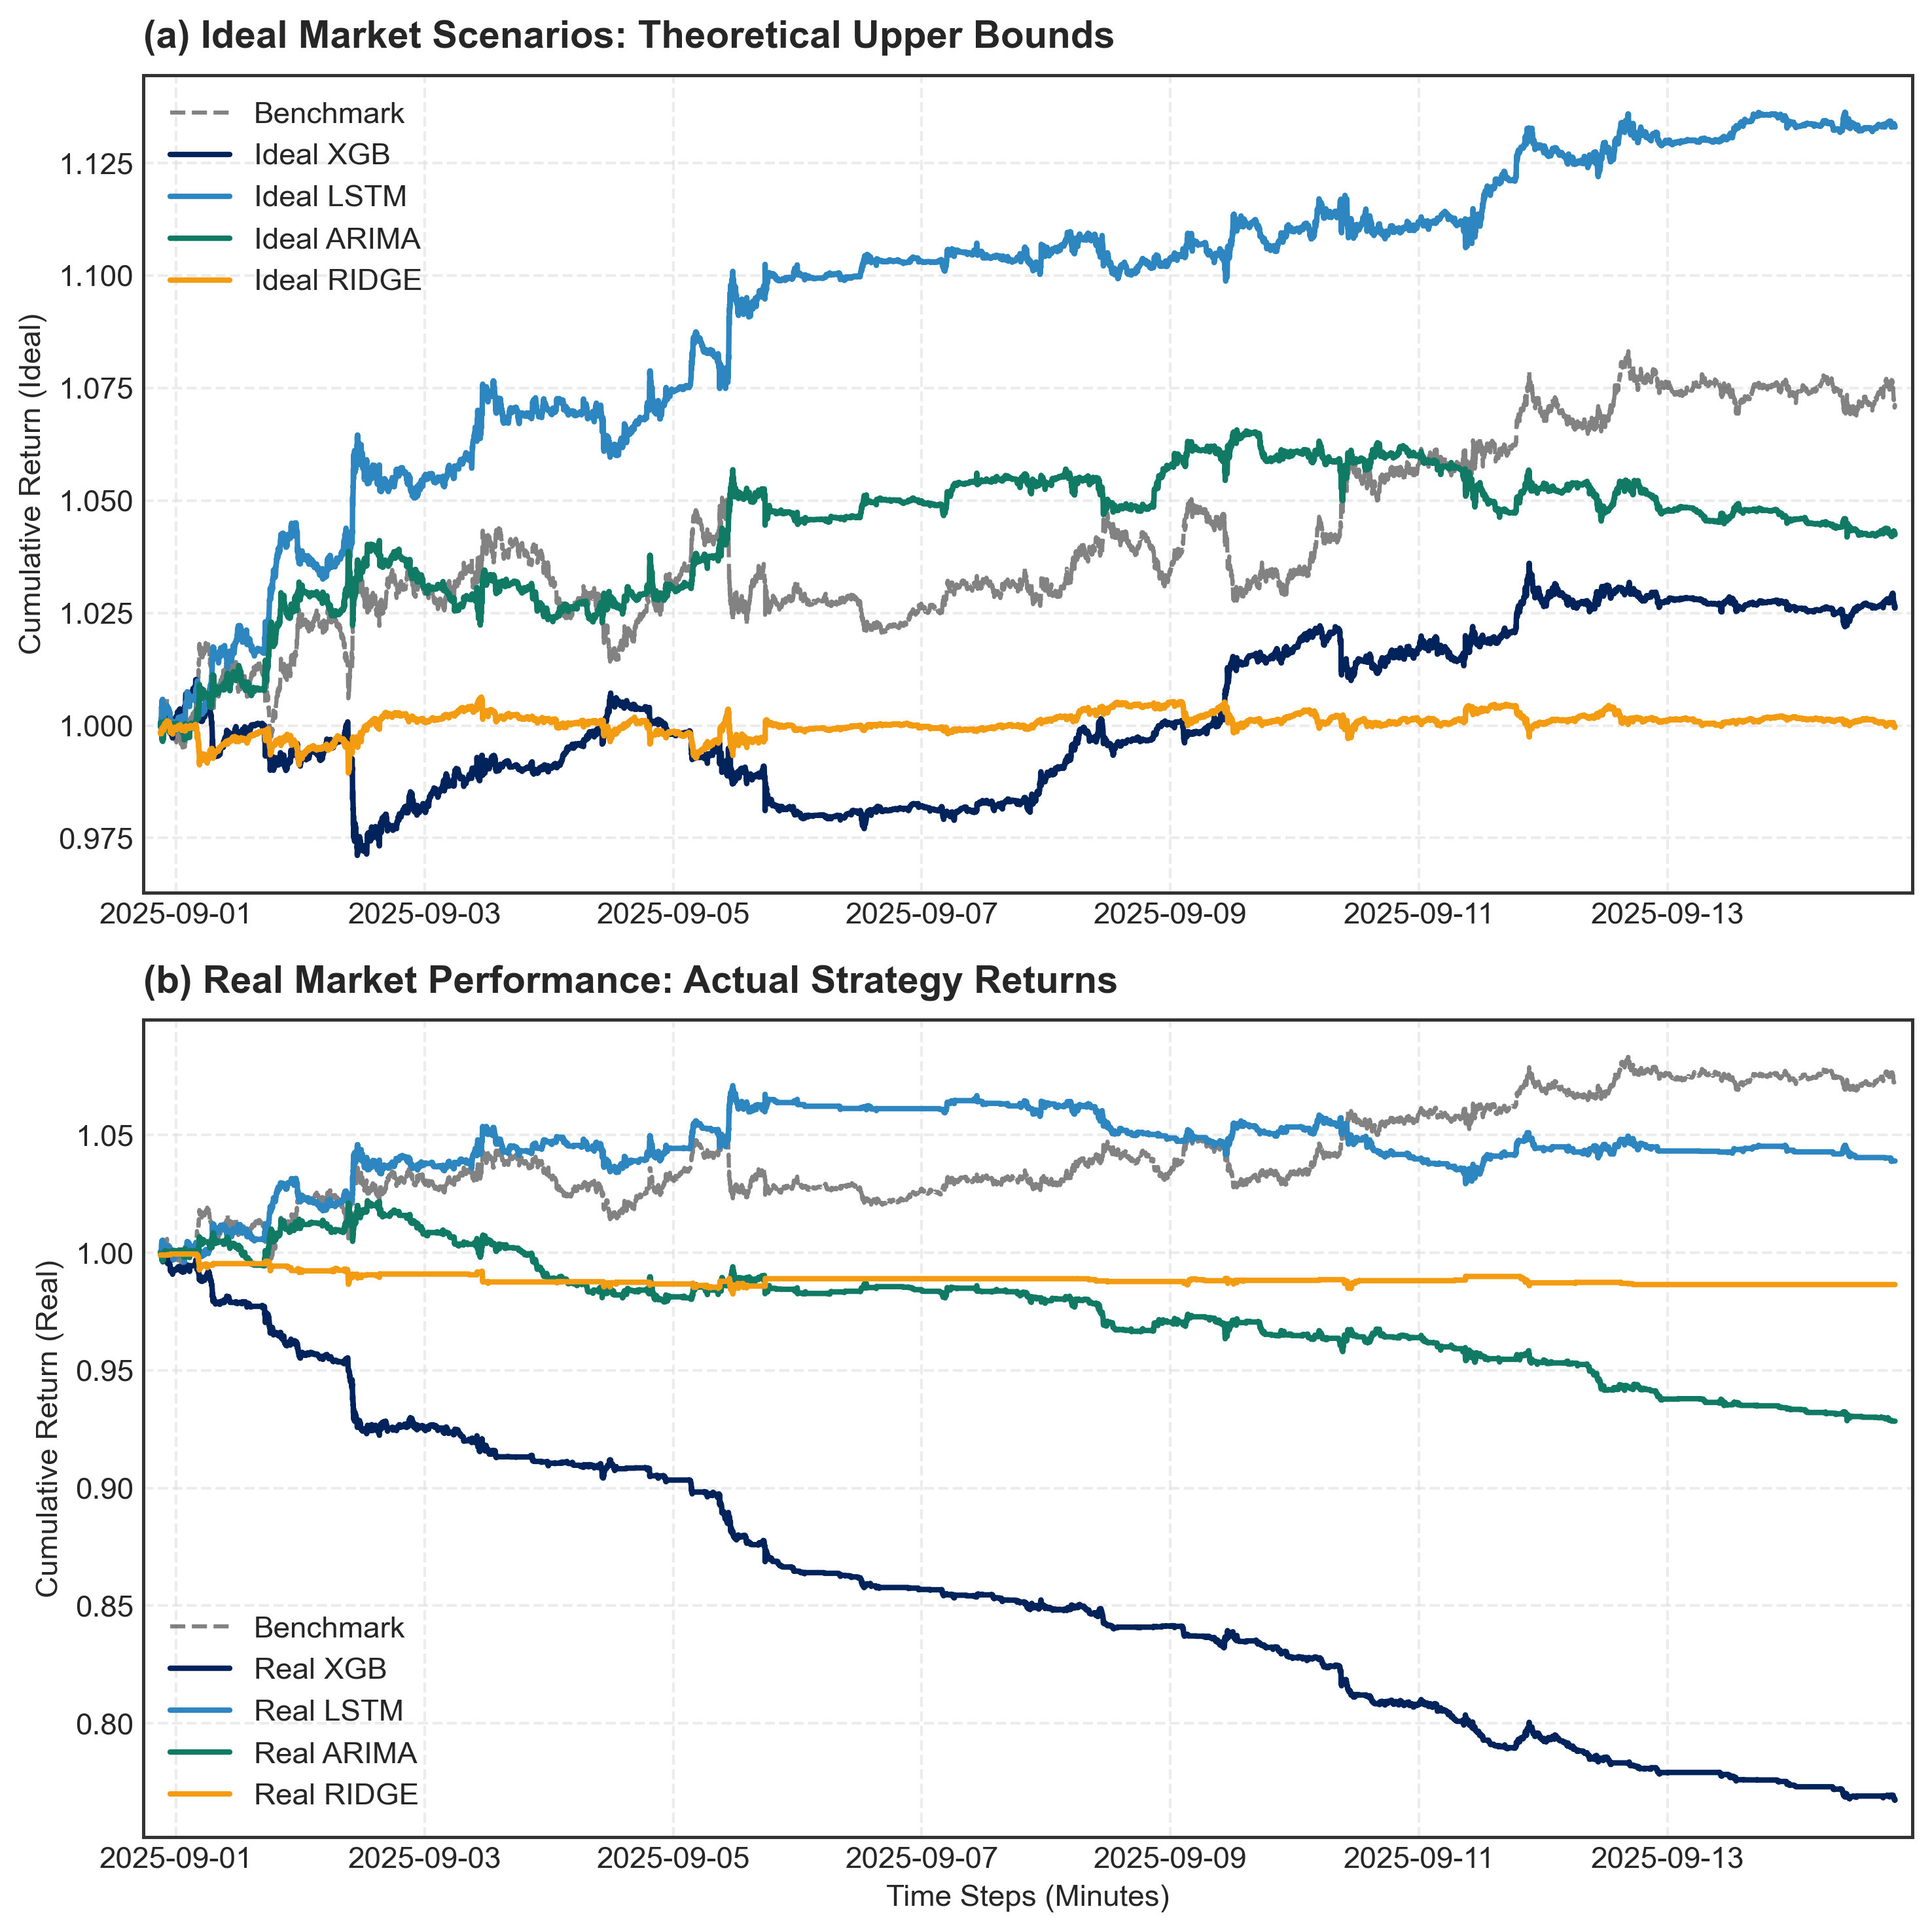

In [6]:
fig = plot_market_scenarios_vertical(df)
plt.show()

In [7]:
ideal_table, real_table = build_metric_tables(df)

print("=== Ideal Market Environment ===")
display(ideal_table)
print()
print("=== Real Market Environment ===")
display(real_table)


=== Ideal Market Environment ===


,Sharpe,Sortino,MaxDD,IR,Treynor,CVaR(5%)
benchmark,0.144512,0.190539,-0.028795,NaN,NaN,-0.000870
arima,0.129708,0.143876,-0.022346,-0.003064,0.000036,-0.000637
lstm,0.333410,0.400172,-0.015771,0.006439,0.000042,-0.000696
ridge,0.009077,0.010137,-0.013392,-0.008354,0.000034,-0.000342
xgb,0.079828,0.083515,-0.038660,-0.004628,-0.000090,-0.000633



=== Real Market Environment ===


,Sharpe,Sortino,MaxDD,IR,Treynor,CVaR(5%)
benchmark,0.144512,0.190539,-0.028795,NaN,NaN,-0.000870
arima,-0.240826,-0.187822,-0.091659,-0.016578,-0.000058,-0.000624
lstm,0.106942,0.102458,-0.038922,-0.003493,0.000014,-0.000694
ridge,-0.106429,-0.033860,-0.017016,-0.010451,-0.000552,-0.000007
xgb,-0.844665,-0.664626,-0.232851,-0.035914,0.000443,-0.000645


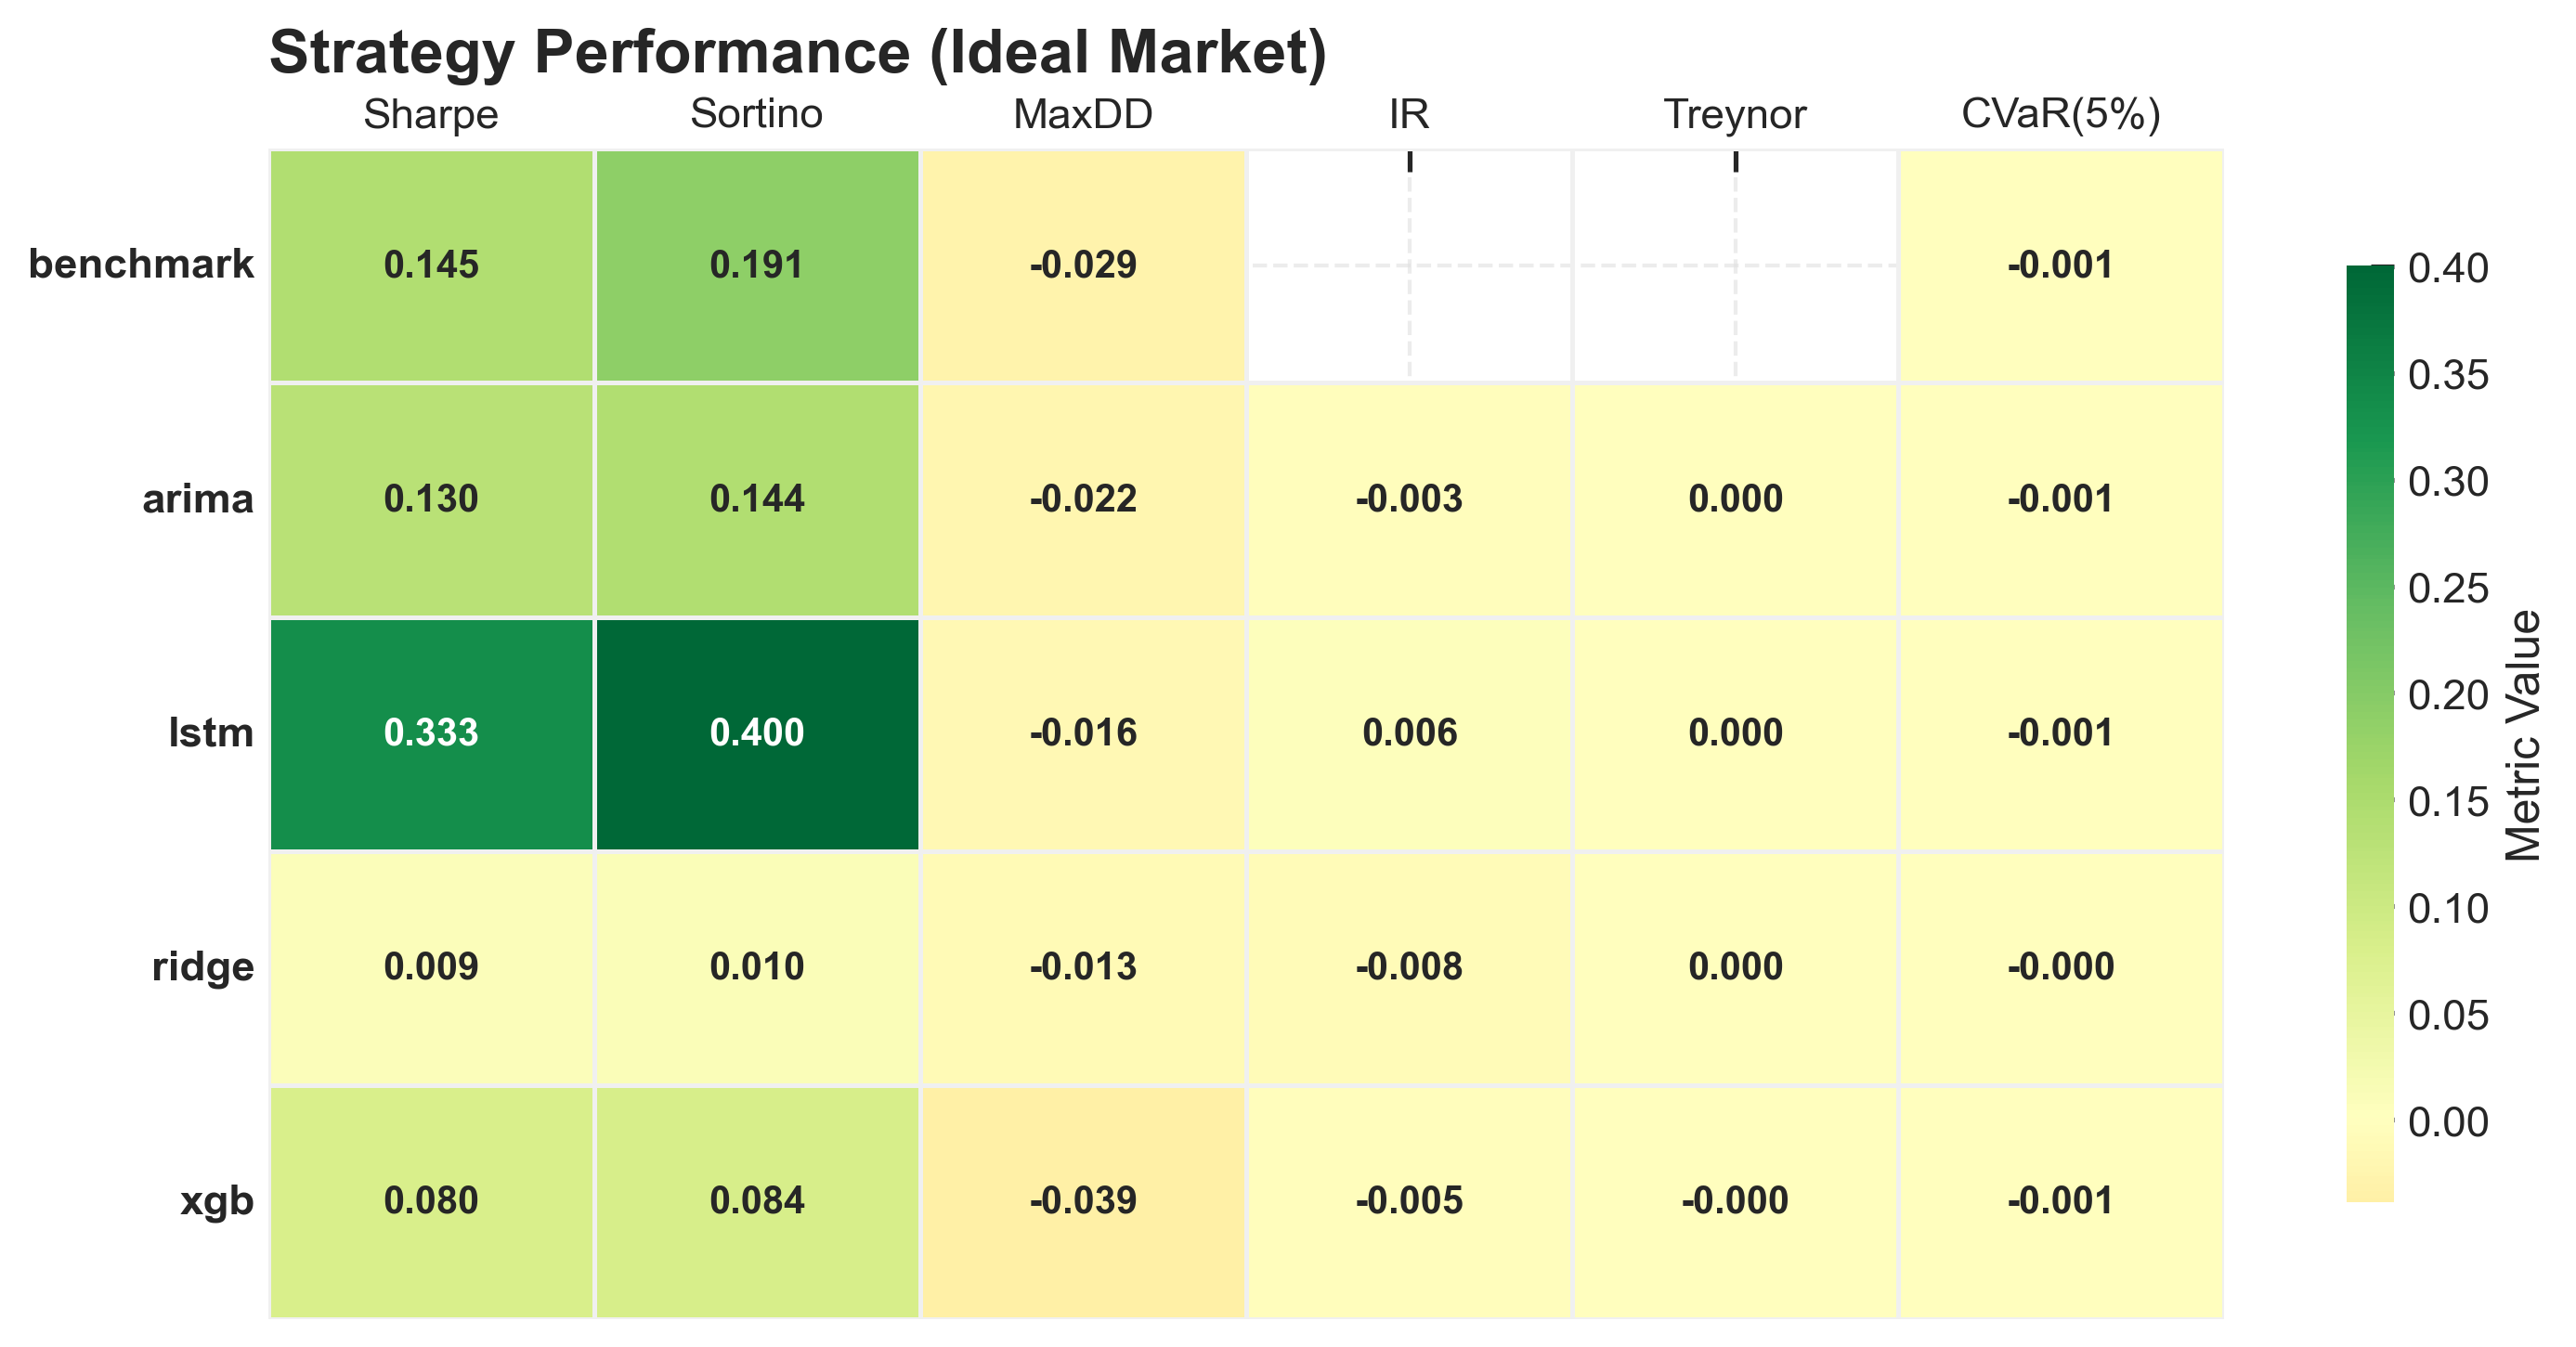

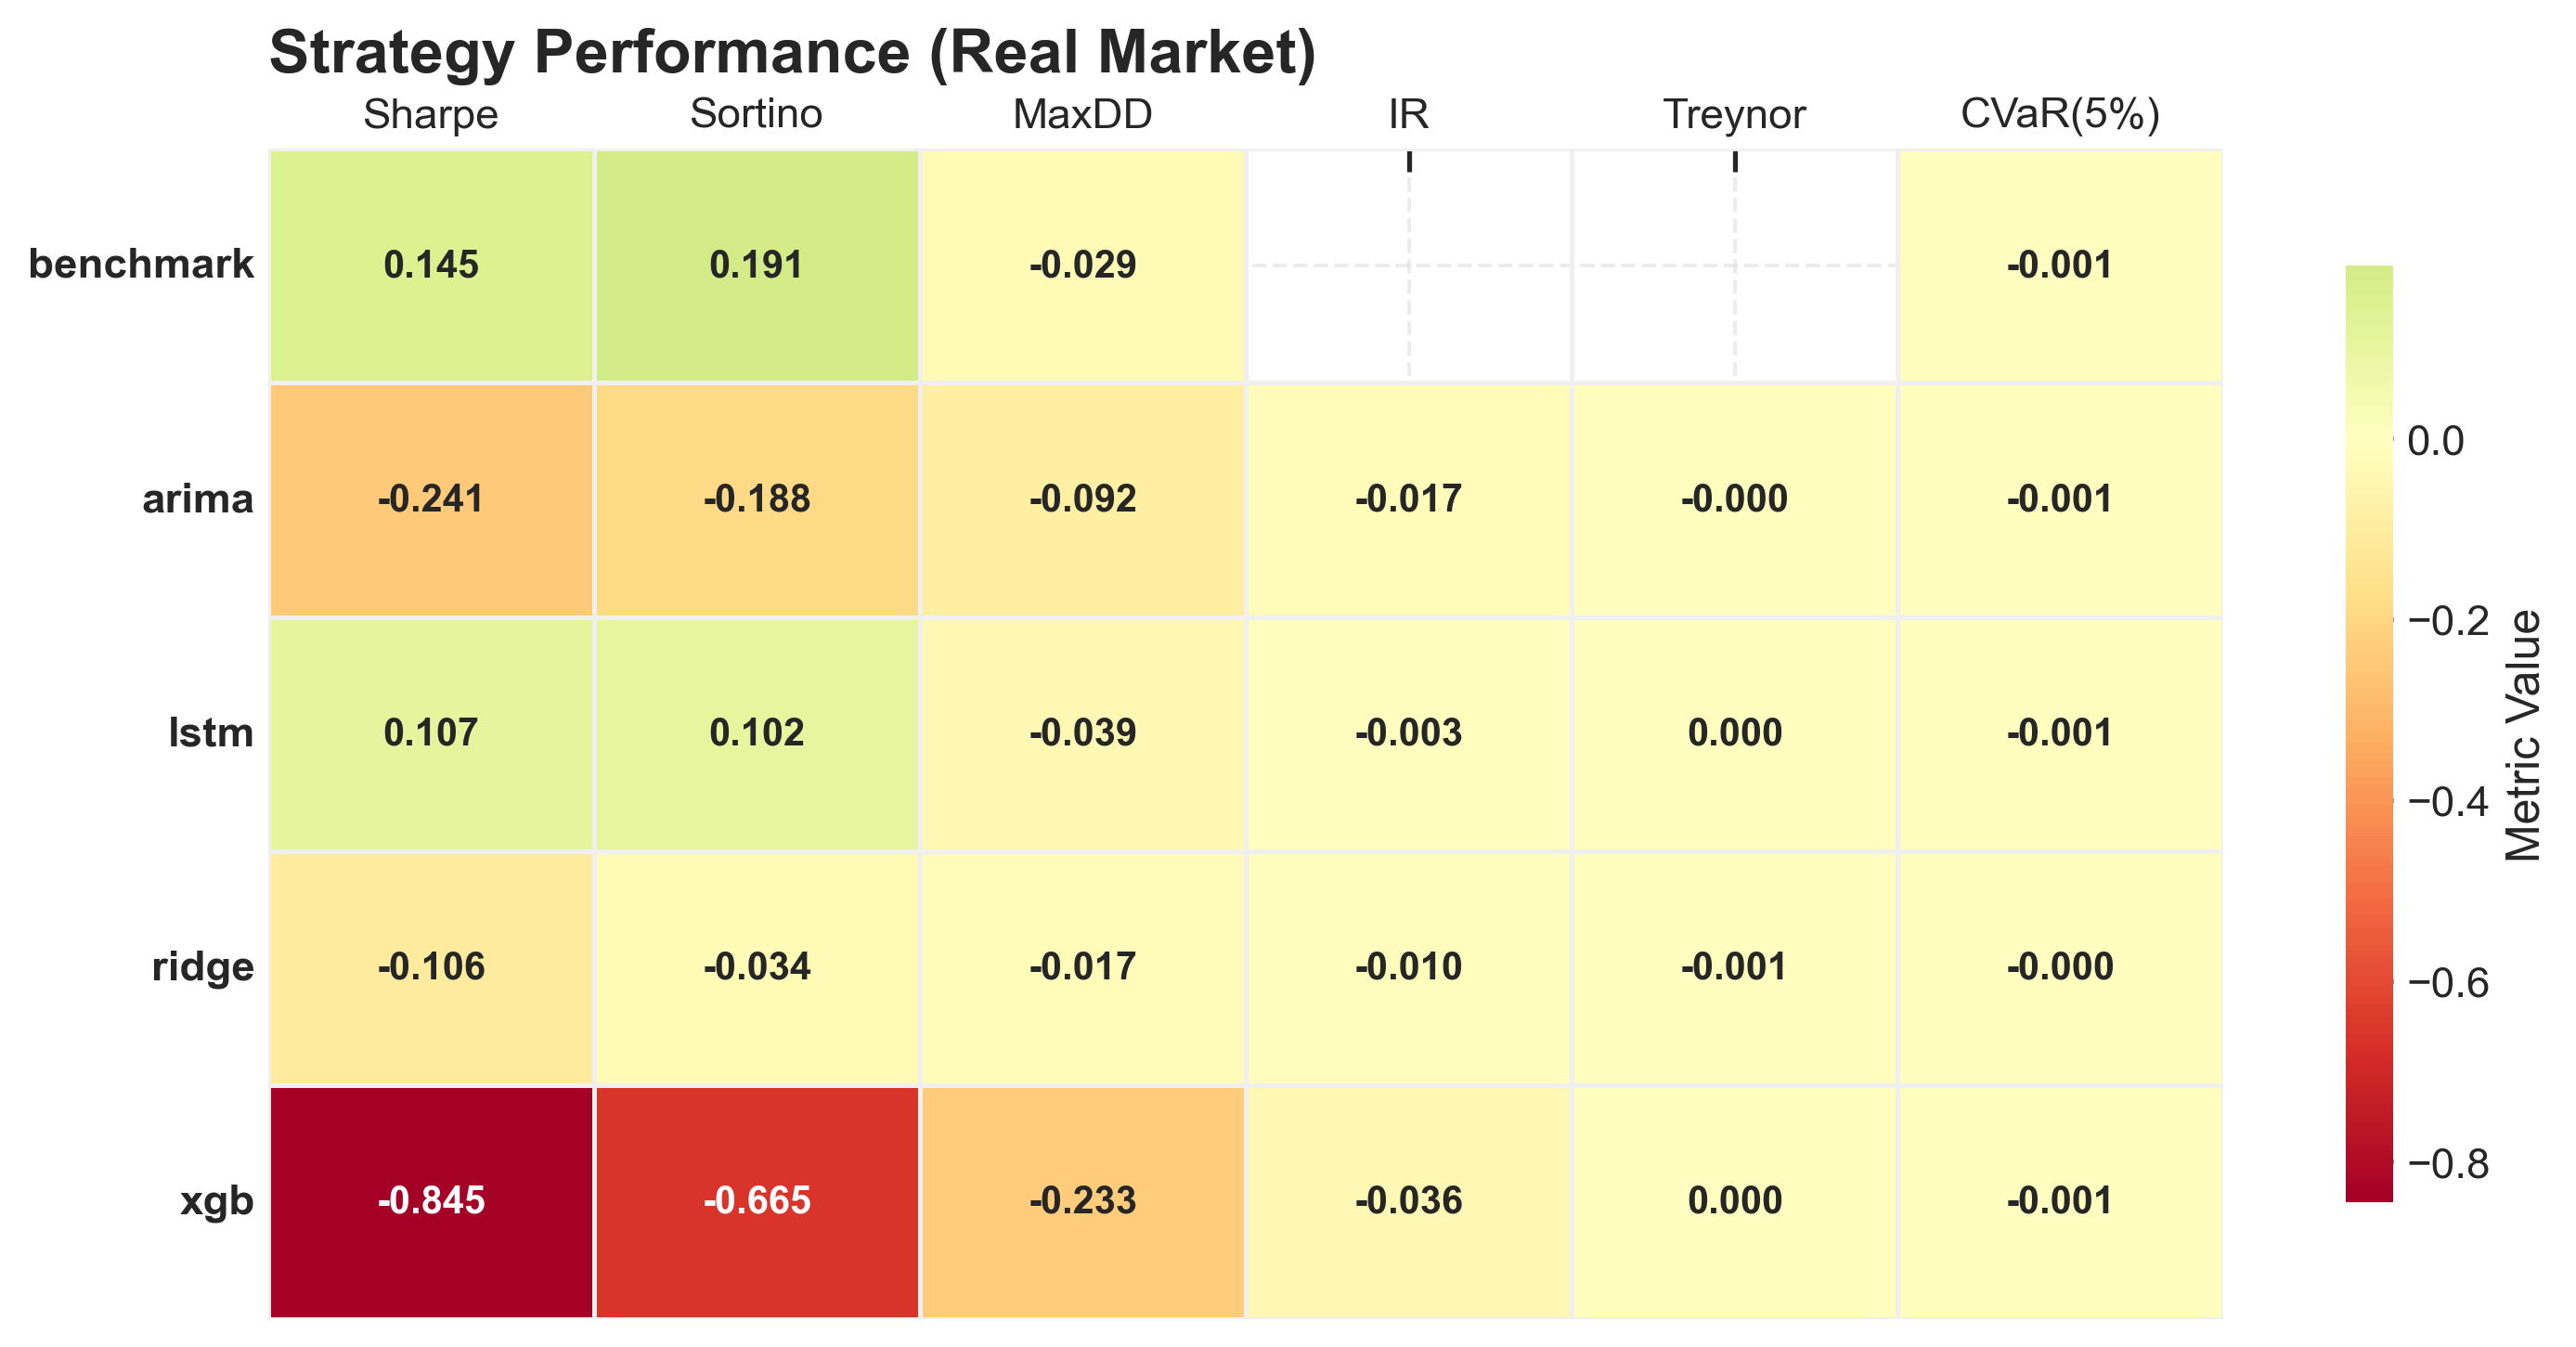

In [8]:
plot_heatmap(ideal_table, "Strategy Performance (Ideal Market)")
plot_heatmap(real_table, "Strategy Performance (Real Market)")

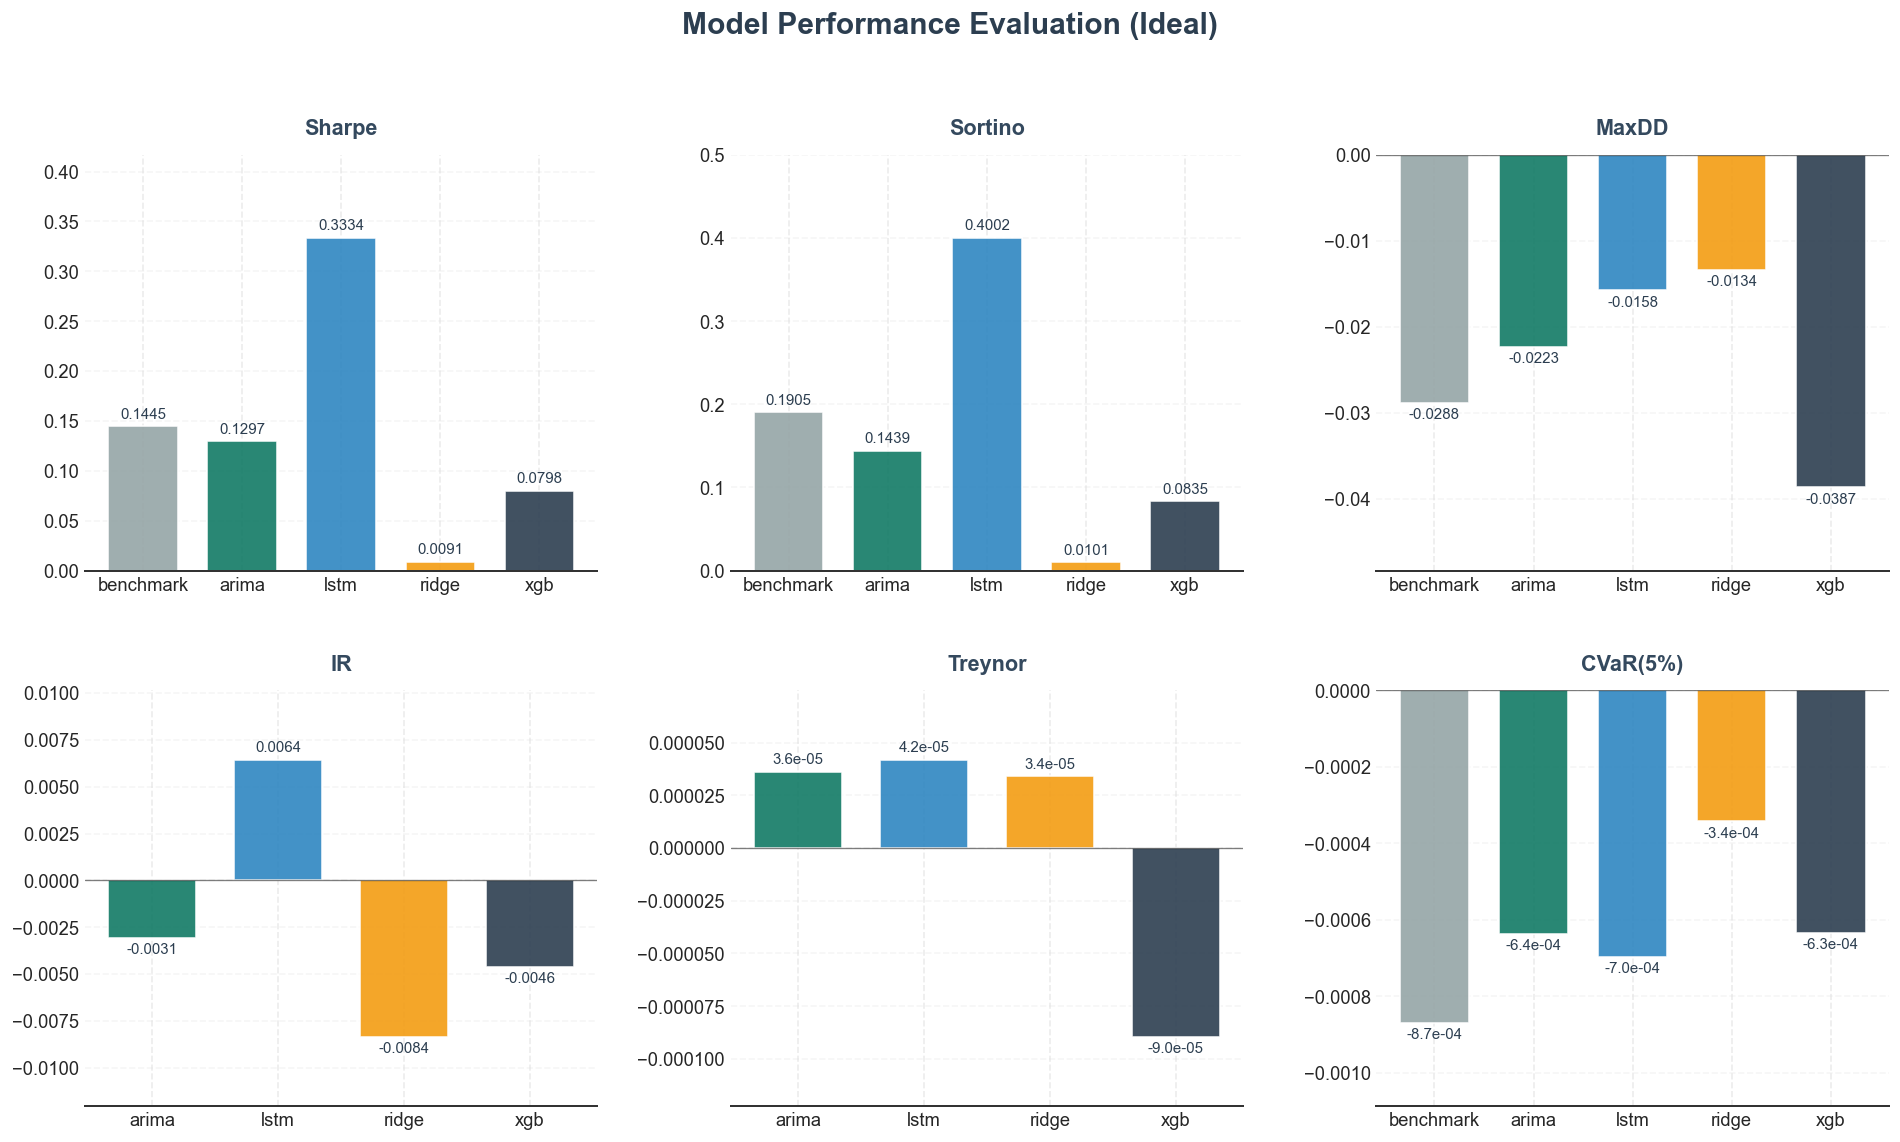

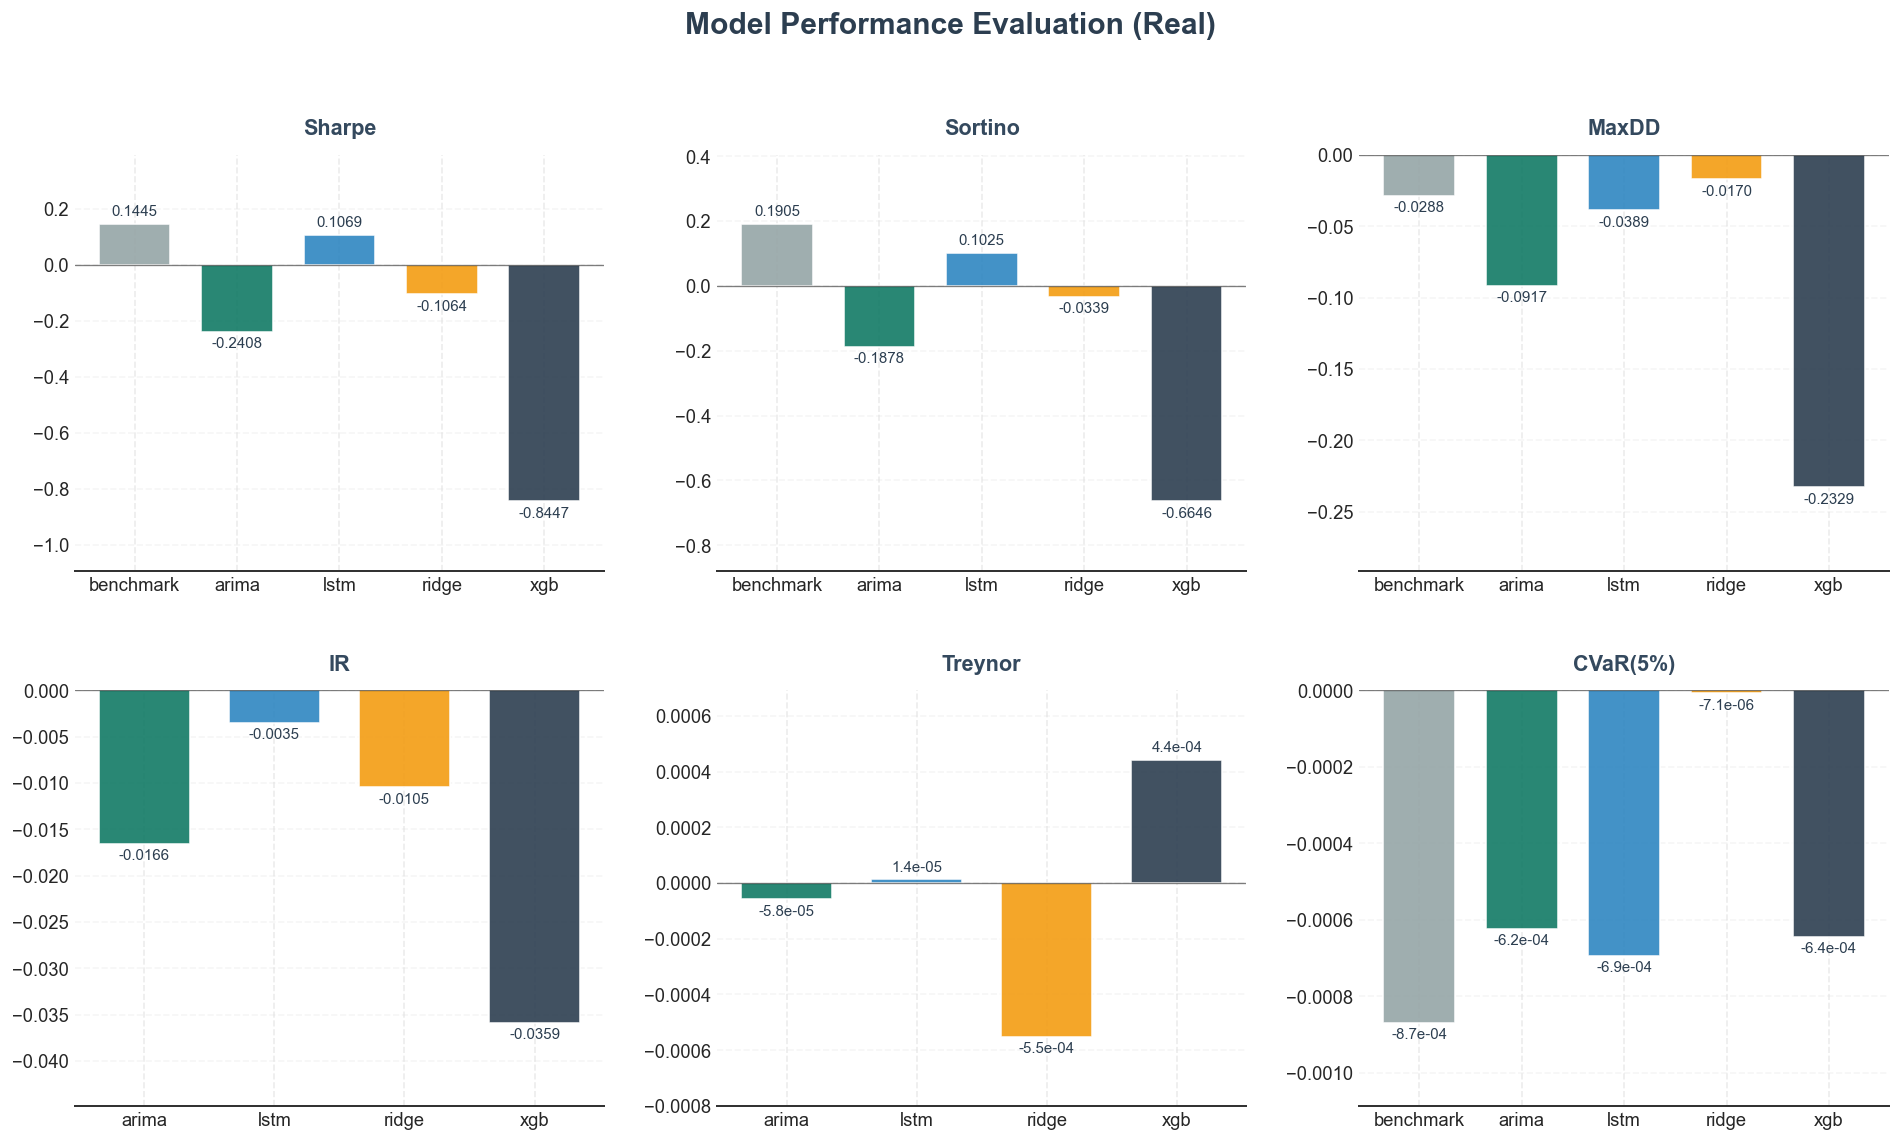

In [9]:
plot_metric_comparison(ideal_table, title="Model Performance Evaluation (Ideal)")
plot_metric_comparison(real_table, title="Model Performance Evaluation (Real)")

## 1. Executive Summary
The backtest results reveal a significant disparity between the **Ideal (Theoretical)** and **Real** market environments. While **LSTM** demonstrated strong potential in the ideal scenario, **no active strategy outperformed the Benchmark** in the real execution environment.

## 2. Key Findings

### 🏆 Best Performer: LSTM
*   **Ideal:** Achieved the highest **Sharpe Ratio (0.333)** and **Sortino Ratio (0.400)**, significantly outperforming the Benchmark (0.145). It also had a low Max Drawdown (-1.58%).
*   **Real:** Performance degraded but remained the **only active strategy with a positive Sharpe Ratio (0.107)**. It is the most robust model but still lagged slightly behind the Benchmark (Sharpe 0.145) and incurred higher risk (MaxDD -3.89%).

### 📉 Underperformers: XGBoost & ARIMA
*   **XGBoost:** Suffered a catastrophic collapse in the Real environment.
    *   **Ideal Sharpe:** 0.080
    *   **Real Sharpe:** -0.845 (Worst)
    *   **Real MaxDD:** -23.29% (Highest Risk)
    *   *Interpretation:* Likely heavily overfitted or extremely sensitive to transaction costs/slippage.
*   **ARIMA:** Also failed to translate theoretical stability into real returns, ending with a negative Sharpe (-0.241) and significant drawdown (-9.17%).

### 🛡️ The Benchmark (Buy & Hold)
*   **Consistency:** The Benchmark remained the standard to beat with a Sharpe of **0.145** and Max Drawdown of **-2.88%**.
*   **Real Reality:** In the Real environment, the Benchmark offered a better risk-adjusted return than all active strategies.

## 3. Metrics Comparison (Real Market)

| Model | Sharpe Ratio | Max Drawdown | Sortino | Verdict |
| :--- | :--- | :--- | :--- | :--- |
| **Benchmark** | **0.145** | -2.88% | **0.191** | 🥇 Best Risk-Adjusted Return |
| **LSTM** | 0.107 | -3.89% | 0.102 | 🥈 Best Active Strategy |
| **Ridge** | -0.106 | **-1.70%** | -0.034 | Conservative but Unprofitable |
| **ARIMA** | -0.241 | -9.17% | -0.188 | Poor Performance |
| **XGB** | -0.845 | -23.29% | -0.665 | ⛔ High Risk / Failed |

## 4. Conclusion & Recommendations
1.  **Model Selection:** **LSTM** is the primary candidate for further optimization. It showed the best generalization from Ideal to Real scenarios.
2.  **Overfitting Check:** **XGBoost** needs a complete overhaul. The massive gap between Ideal and Real performance suggests it learned noise or relied on unrealistic execution assumptions.
3.  **Risk Management:** **Ridge** had the lowest drawdown (-1.70%), suggesting its signal is stable but too weak to generate alpha. Combining Ridge's stability with LSTM's predictive power (Ensemble) might be worth exploring.